In [ ]:
import pandas as pd
import torch
from transformers import RobertaTokenizerFast
from torch.utils.data import Dataset

#GPU Check
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware Check: Using device -> {device}")

Hardware Check: Using device -> cuda


In [ ]:
# Load the data
df_train = pd.read_csv("/content/train_text_data.csv")
df_test = pd.read_csv('/content/test_text_data.csv')

# Extract text and labels
train_texts = df_train['text_'].fillna("").tolist()
test_texts = df_test['text_'].fillna("").tolist()

y_train = df_train['label'].values
y_test = df_test['label'].values

In [ ]:
# Initialize Tokenizer
print("Loading RoBERTa Tokenizer...")
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

# Tokenize Data
print("Tokenizing training and test data...")
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=256, return_tensors='pt')
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=256, return_tensors='pt')

print(f"Tokenization complete! Train Input IDs shape: {train_encodings['input_ids'].shape}")

Loading RoBERTa Tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training and test data...
Tokenization complete! Train Input IDs shape: torch.Size([32345, 256])


In [ ]:
import numpy as np
from torch.utils.data import Dataset
from transformers import RobertaForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, f1_score
import torch

# 1. Create the PyTorch Dataset Class
class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: val[idx].clone().detach() for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# 2. Initialize the Datasets
print("Creating PyTorch Datasets...")
train_dataset = ReviewDataset(train_encodings, y_train)
test_dataset = ReviewDataset(test_encodings, y_test)

# 3. Load a FRESH RoBERTa sequence classifier
print("Loading a fresh RoBERTa model...")
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=2)

# 4. Define Evaluation Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro')
    return {'accuracy': acc, 'f1': f1}

# 5. Setup Training Arguments
training_args = TrainingArguments(
    output_dir='./roberta_fake_reviews',
    num_train_epochs=4,                  # Increased to 4 for the warmup period
    per_device_train_batch_size=8,       # Kept your lower batch size!
    per_device_eval_batch_size=4,        # Kept your lower batch size!
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    logging_dir='./logs',
    logging_steps=50,
    fp16=True,
    learning_rate=1e-5,                  # Lowered to 1e-5
    weight_decay=0.01,
    warmup_ratio=0.1,                    # Added the warmup ratio to prevent the 50% crash
)

# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# 7. Start Training!
print("Starting the Fine-Tuning process with Warmup... 🚀")
trainer.train()

# 8. Save the best model
model.save_pretrained('./fine_tuned_roberta')
tokenizer.save_pretrained('./fine_tuned_roberta')
print("✅ Fine-tuned model saved successfully!")

Creating PyTorch Datasets...
Loading a fresh RoBERTa model...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated 

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Fine-tuned model saved successfully!


Extracting train and test predictions...


✅ Saved train and test RoBERTa probabilities!


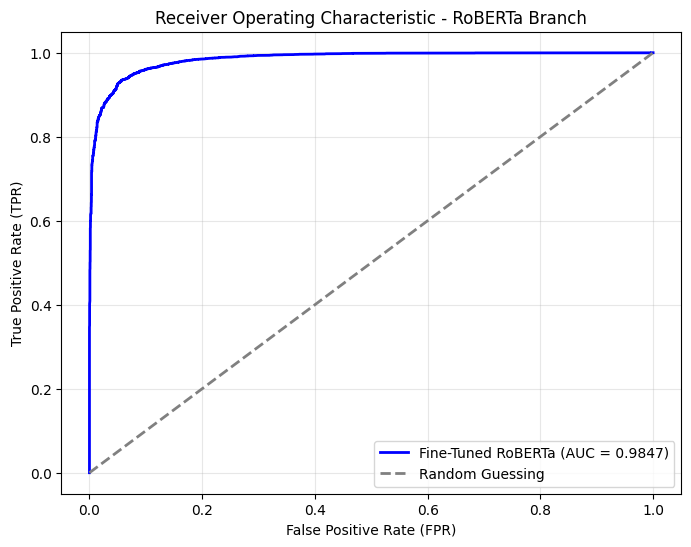

In [ ]:
import matplotlib.pyplot as plt
import torch.nn.functional as F
from sklearn.metrics import roc_curve, auc
import pandas as pd
import torch

# 1. Get raw predictions (logits) from the fine-tuned Trainer
print("Extracting train and test predictions...")
train_preds = trainer.predict(train_dataset)
test_preds = trainer.predict(test_dataset)

# 2. Convert logits to standard probabilities (0.0 to 1.0) using Softmax
# We slice [:, 1] to get the probability of class 1 (AI/Fake)
train_probs = F.softmax(torch.tensor(train_preds.predictions), dim=-1)[:, 1].numpy()
test_probs = F.softmax(torch.tensor(test_preds.predictions), dim=-1)[:, 1].numpy()

# 3. Save the probabilities for the Final Fusion Layer
pd.DataFrame({'roberta_prob': train_probs}).to_csv('train_roberta_probabilities.csv', index=False)
pd.DataFrame({'roberta_prob': test_probs}).to_csv('test_roberta_probabilities.csv', index=False)
print("✅ Saved train and test RoBERTa probabilities!")

# 4. Plot the ROC-AUC Curve for the Test Set
fpr, tpr, _ = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Fine-Tuned RoBERTa (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing')
plt.title('Receiver Operating Characteristic - RoBERTa Branch')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()